# Predicción del nivel de comisiones por bloque en la red Bitcoin

Proyecto Final de Machine Learning (CS3061) — UTEC, 2026-2
**Etapa 1: formulación del problema, descripción del dataset y análisis exploratorio.**

---

## 1. El problema

Cuando una persona emite una transacción en Bitcoin debe elegir cuánta comisión ofrece a los
mineros. Esa elección determina si la transacción se confirma pronto o permanece en espera:

- Si ofrece **poco**, la transacción puede tardar horas o días en confirmarse, o no confirmarse.
- Si ofrece **de más**, paga un sobrecosto innecesario que no puede recuperar, porque las
  transacciones en Bitcoin son irreversibles.

El espacio en un bloque es limitado y los mineros seleccionan qué transacciones incluyen. Cuando
la demanda supera esa capacidad, se forma una subasta: los usuarios compiten ofreciendo
comisiones mayores. El precio resultante varía de forma considerable en cuestión de horas.

Las carteras incorporan estimadores de comisión para asistir esta decisión, pero su desempeño es
limitado, sobre todo en los episodios de mayor congestión, que son justamente aquellos en los que
el usuario más necesita una estimación correcta.

## 2. Objetivo

Determinar si, a partir del estado observable de la red hasta el bloque actual, es posible
anticipar si la comisión del siguiente bloque será **alta respecto al nivel vigente del mercado**.

El resultado no constituye un estimador de comisión completo, sino su primer componente: la
estimación del nivel de precio del mercado, sobre la cual un estimador operativo aplicaría después
el criterio de urgencia de cada usuario.

## 3. Formulación como problema de aprendizaje (E, T, P)

**Tarea (T).** Clasificación binaria. Dado el bloque *t* y su historia, predecir si la tasa
mediana de comisión del bloque *t+1* superará el percentil 75 de los bloques recientes.

**Experiencia (E).** 419 727 pares (bloque, bloque siguiente) construidos a partir del registro de
la cadena de bloques de Bitcoin entre enero de 2016 y octubre de 2023. La delimitación del periodo
se justifica en la sección 10. Cada bloque aporta trece atributos observables en el momento de su
publicación: altura, marca de tiempo, tamaño, número de transacciones, dificultad de minería,
tasas de comisión mediana, promedio, mínima y máxima, comisiones totales, número de entradas y de
salidas, y valor total de salidas.

**Medida de desempeño (P).** F1 sobre la clase «alta» y área bajo la curva de precisión-cobertura
(PR-AUC), evaluadas sobre una partición temporal posterior a la de entrenamiento. No se emplea la
exactitud como métrica principal: con clases desbalanceadas, un clasificador que prediga siempre
la clase mayoritaria obtiene valores altos sin capacidad predictiva. Toda comparación se realiza
contra una referencia de persistencia, que predice para el bloque *t+1* la clase observada en *t*.

## 4. Alcance: qué se predice y qué no

Estas delimitaciones se derivan de la naturaleza de los datos disponibles y condicionan la
interpretación de cualquier resultado.

- **Se predice el nivel de comisión, no la ocupación del bloque.** La ocupación es la condición
  que da origen al mercado de comisiones, y se analiza en la sección 10 con ese propósito, pero no
  es la variable objetivo. Dentro del periodo estudiado los bloques operan cerca de su capacidad de
  forma habitual, por lo que su llenado no es un evento informativo.
- **Se modela el mercado agregado, no la decisión individual.** La unidad de observación es el
  bloque, que resume cientos o miles de transacciones. El conjunto de datos no contiene el
  historial de transacciones individuales, por lo que no es posible estimar la probabilidad de
  inclusión de una transacción concreta.
- **Los datos describen transacciones confirmadas.** Las transacciones que ofrecieron comisiones
  insuficientes y nunca se incluyeron en un bloque no aparecen en el registro. Se observa el
  resultado de la subasta, no el conjunto de ofertas.
- **No se dispone del estado del mempool.** La cola de transacciones pendientes es un estado
  transitorio que no puede reconstruirse retrospectivamente. La congestión se aproxima mediante la
  ocupación de los bloques y las propias tasas observadas.

## 5. Preguntas de investigación

1. ¿La tasa de comisión del bloque actual permite anticipar la del siguiente por encima de lo que
   logra una regla de persistencia?
2. ¿Qué atributos del estado de la red aportan información adicional a la tasa reciente?
3. ¿El desempeño del clasificador se mantiene estable entre periodos de congestión alta y baja
   dentro del periodo de estudio?

## 6. Hipótesis

- **H1.** La tasa de comisión reciente es el predictor dominante, dada la persistencia observada
  en series de esta naturaleza.
- **H2.** Los atributos de actividad de la red —número de transacciones y comisiones totales—
  aportan una mejora marginal sobre H1, menor que la contribución de la propia tasa.
- **H3.** El desempeño se degrada en los episodios de mayor variación del nivel de comisiones, que
  son aquellos en los que una estimación correcta resulta más valiosa.

## 7. Plan de trabajo

**Etapa 1 (este documento).** Descripción del conjunto de datos, revisión de su calidad,
delimitación del periodo de estudio, análisis exploratorio, definición y validación de la variable
objetivo, y diseño de la partición experimental. No se entrenan modelos.

**Etapa 2.** Construcción de variables derivadas, entrenamiento de una referencia de persistencia
y de modelos de clasificación, validación con ventana expansiva y evaluación segmentada por nivel
de congestión. El detalle figura en la sección 20.

---

## 8. Conjunto de datos

Cada fila del conjunto de datos representa un **bloque** de la cadena. El archivo de origen abarca
de enero de 2009 a octubre de 2023; el estudio se restringe a los bloques posteriores al 1 de enero
de 2016, por las razones que se documentan en la sección 10. Las revisiones de calidad de la
sección 9 se realizan sobre el archivo completo, antes de aplicar esa delimitación.

Fuente: Jesús Graterol, [Bitcoin Blockchain Historical Data](https://www.kaggle.com/datasets/jesusgraterol/bitcoin-blockchain-dataset), Kaggle.

### 8.1 Importar las librerías

Pandas permite trabajar con tablas y Matplotlib crear gráficos.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt


### 8.2 Cargar y observar el dataset

El notebook y `dataset.csv` están en la misma carpeta. Se ejecuta desde `eda/`.


In [2]:
df = pd.read_csv("dataset.csv")
df.head()


,height,timestamp,size,tx_count,difficulty,median_fee_rate,avg_fee_rate,total_fees,fee_range_min,fee_range_max,input_count,output_count,output_amount
0,1,1231469665000,215,1,1.0,0.0,0,0,0.0,0.0,0,1,0
1,2,1231469744000,215,1,1.0,0.0,0,0,0.0,0.0,0,1,0
2,3,1231470173000,215,1,1.0,0.0,0,0,0.0,0.0,0,1,0
3,4,1231470988000,215,1,1.0,0.0,0,0,0.0,0.0,0,1,0
4,5,1231471428000,215,1,1.0,0.0,0,0,0.0,0.0,0,1,0


In [3]:
print("Filas y columnas:", df.shape)
df.info()


Filas y columnas: (810909, 13)
<class 'pandas.DataFrame'>
RangeIndex: 810909 entries, 0 to 810908
Data columns (total 13 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   height           810909 non-null  int64  
 1   timestamp        810909 non-null  int64  
 2   size             810909 non-null  int64  
 3   tx_count         810909 non-null  int64  
 4   difficulty       810909 non-null  float64
 5   median_fee_rate  810909 non-null  float64
 6   avg_fee_rate     810909 non-null  int64  
 7   total_fees       810909 non-null  int64  
 8   fee_range_min    810909 non-null  float64
 9   fee_range_max    810909 non-null  float64
 10  input_count      810909 non-null  int64  
 11  output_count     810909 non-null  int64  
 12  output_amount    810909 non-null  int64  
dtypes: float64(4), int64(9)
memory usage: 80.4 MB


### 8.3 Descripción de las variables

| Columna | Significado |
|---|---|
| `height` | Altura: posición del bloque en la cadena, desde el bloque génesis |
| `timestamp` | Momento de minado del bloque, como marca de tiempo Unix en milisegundos |
| `size` | Tamaño del bloque en bytes |
| `tx_count` | Número de transacciones incluidas en el bloque |
| `difficulty` | Dificultad de minería vigente, ajustada por el protocolo cada 2016 bloques |
| `median_fee_rate` | **Variable de interés.** Mediana de las tasas de comisión pagadas por las transacciones incluidas en el bloque, en satoshis por byte |
| `avg_fee_rate` | Promedio de las tasas de comisión pagadas por las transacciones del bloque |
| `total_fees` | Suma de las comisiones recaudadas por el minero del bloque, en satoshis |
| `fee_range_min` | Tasa de comisión más baja pagada por una transacción del bloque |
| `fee_range_max` | Tasa de comisión más alta pagada por una transacción del bloque |
| `input_count` | Número total de entradas de todas las transacciones del bloque |
| `output_count` | Número total de salidas de todas las transacciones del bloque |
| `output_amount` | Valor total de todas las salidas del bloque, en satoshis |

**Sobre `median_fee_rate`.** Un bloque contiene cientos o miles de transacciones, cada una con su
propia comisión. Esta columna toma el valor central de esa distribución. Se interpreta como el
precio aproximado que era necesario ofrecer para que una transacción fuese incluida en ese bloque:
si vale 20, una transacción que ofreciera alrededor de 20 satoshis por byte tenía posibilidades
razonables de entrar.

El objetivo del proyecto se construye a partir de esta columna, desplazada un bloque hacia
adelante.

Las entradas y salidas no representan personas ni cuentas únicas: una misma transacción puede
tener varias de cada una.

## 9. Calidad de los datos

Las revisiones de esta sección se realizan sobre el archivo completo, antes de delimitar el
periodo de estudio.

### 9.1 Valores faltantes y duplicados


In [4]:
df.isna().sum()

height             0
timestamp          0
size               0
tx_count           0
difficulty         0
median_fee_rate    0
avg_fee_rate       0
total_fees         0
fee_range_min      0
fee_range_max      0
input_count        0
output_count       0
output_amount      0
dtype: int64

In [5]:
datos_completos = df.copy()

print("Filas duplicadas:", df.duplicated().sum())
print("Alturas repetidas:", df["height"].duplicated().sum())
print("Valores negativos por columna:")
df.lt(0).sum()

Filas duplicadas: 0
Alturas repetidas: 0
Valores negativos por columna:


height             0
timestamp          0
size               0
tx_count           0
difficulty         0
median_fee_rate    0
avg_fee_rate       0
total_fees         0
fee_range_min      0
fee_range_max      0
input_count        0
output_count       0
output_amount      0
dtype: int64

### 9.2 Coherencia interna de las tasas

Por definición, la mediana de un conjunto de valores debe situarse entre su mínimo y su máximo. Se
verifica que `median_fee_rate` esté contenida en el intervalo `[fee_range_min, fee_range_max]` del
mismo bloque.

In [6]:
fuera_de_rango = ((datos_completos["median_fee_rate"] < datos_completos["fee_range_min"]) |
                  (datos_completos["median_fee_rate"] > datos_completos["fee_range_max"]))

print("Bloques con mediana fuera del rango publicado:", fuera_de_rango.sum())
print("Porcentaje:", round(fuera_de_rango.mean() * 100, 2))
print("Bloques con promedio por encima del máximo:",
      (datos_completos["avg_fee_rate"] > datos_completos["fee_range_max"]).sum())

Bloques con mediana fuera del rango publicado: 2512
Porcentaje: 0.31
Bloques con promedio por encima del máximo: 0


2 512 bloques (0,31 %) presentan una mediana fuera del rango publicado, situación
imposible si las tres columnas describieran el mismo conjunto de transacciones. El promedio,
en cambio, nunca supera el máximo.

La inconsistencia proviene de la fuente y no de esta copia. Se documenta y se conservan las
filas; si esas columnas se utilizaran como variables de entrada en la etapa 2, convendría
excluir los bloques afectados o tratarlos por separado.

En esta copia no se encontraron nulos, duplicados ni valores negativos. Por ello, no se necesita
rellenar datos ni eliminar filas por esos motivos. Esto no garantiza que todas las mediciones estén
libres de problemas.

Se ordena por `height`. Las fechas registradas pueden retroceder entre bloques consecutivos: el
protocolo admite que la marca de tiempo de un bloque sea anterior a la del precedente siempre que
supere la mediana de los once bloques previos. No representan tiempos de espera de una
transacción.

In [7]:
df = df.sort_values("height").reset_index(drop=True)

print("Saltos de altura distintos de 1:", df["height"].diff().dropna().ne(1).sum())
print("Retrocesos del timestamp:", df["timestamp"].diff().lt(0).sum())

assert df["height"].diff().dropna().eq(1).all()


Saltos de altura distintos de 1: 0
Retrocesos del timestamp: 14572


## 10. Delimitación del periodo de estudio

La comisión de una transacción se determina por competencia solo cuando el espacio en el bloque es
escaso. Si los bloques no se llenan, cualquier transacción entra y la comisión la fijan las reglas
del software cliente, no la demanda. Esa distinción es determinante para este proyecto, que modela
precisamente el resultado de esa competencia.

Existieron comisiones en Bitcoin desde 2009: el protocolo las contempla desde el diseño original.
Lo que se verifica aquí es otra cuestión: **desde cuándo el espacio en bloque constituye un recurso
escaso.**

Se mide, para cada año, la proporción de bloques cercanos al límite de capacidad y la correlación
entre la tasa de un bloque y la del siguiente. **La ocupación no es la variable objetivo**: se
analiza porque determina si el fenómeno que el proyecto modela está presente en cada tramo del
periodo. El cálculo usa el archivo completo y es estructural: no estima ningún parámetro del
modelo.

In [8]:
fecha_archivo = pd.to_datetime(df["timestamp"], unit="ms", utc=True)

filas_regimen = []
for anio_actual in range(2012, 2024):
    del_anio = df[fecha_archivo.dt.year == anio_actual]
    siguiente = del_anio["median_fee_rate"].shift(-1)
    filas_regimen.append({
        "anio": anio_actual,
        "bloques": len(del_anio),
        "pct_bloques_llenos": (del_anio["size"] > 900_000).mean() * 100,
        "pct_tasa_cero": (del_anio["median_fee_rate"] == 0).mean() * 100,
        "mediana_tasa": del_anio["median_fee_rate"].median(),
        "corr_con_siguiente": del_anio["median_fee_rate"].corr(siguiente),
    })

regimen_anual = pd.DataFrame(filas_regimen).set_index("anio")
regimen_anual.round(3)

,bloques,pct_bloques_llenos,pct_tasa_cero,mediana_tasa,corr_con_siguiente
anio,,,,,
2012,54526,0.000,37.199,59.0,0.049
2013,63433,0.043,7.094,76.0,0.020
2014,58865,1.145,4.497,20.0,0.090
2015,54321,16.820,6.362,19.0,0.124
2016,54851,62.781,2.126,39.0,0.205
2017,55928,89.252,1.025,134.0,0.702
2018,54498,66.059,0.872,8.0,0.866
2019,54232,79.484,0.625,16.0,0.743
2020,53222,87.522,0.490,21.0,0.719


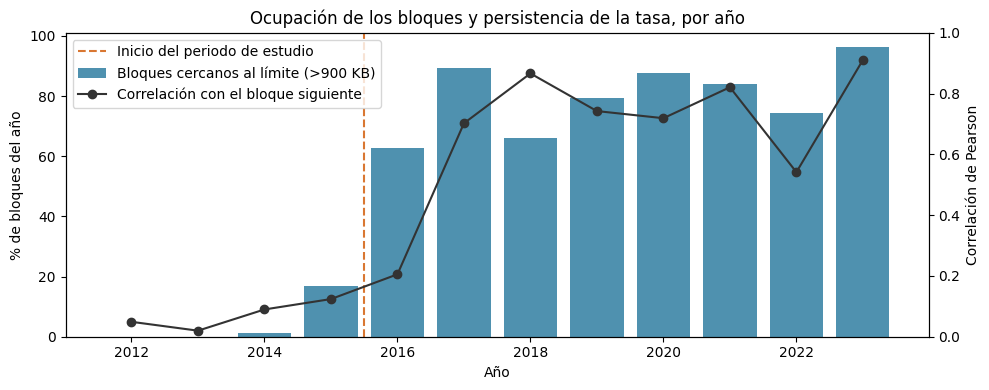

In [9]:
fig, ax1 = plt.subplots(figsize=(10, 4))

ax1.bar(regimen_anual.index, regimen_anual["pct_bloques_llenos"],
        color="#146C94", alpha=0.75, label="Bloques cercanos al límite (>900 KB)")
ax1.axvline(2015.5, color="#D97732", linestyle="--", label="Inicio del periodo de estudio")
ax1.set_ylabel("% de bloques del año")
ax1.set_xlabel("Año")

ax2 = ax1.twinx()
ax2.plot(regimen_anual.index, regimen_anual["corr_con_siguiente"],
         color="#333333", marker="o", label="Correlación con el bloque siguiente")
ax2.set_ylabel("Correlación de Pearson")
ax2.set_ylim(0, 1)

ax1.set_title("Ocupación de los bloques y persistencia de la tasa, por año")
lineas1, etiquetas1 = ax1.get_legend_handles_labels()
lineas2, etiquetas2 = ax2.get_legend_handles_labels()
ax1.legend(lineas1 + lineas2, etiquetas1 + etiquetas2, loc="upper left")
plt.tight_layout()
plt.show()

La proporción de bloques cercanos al límite pasa de 0,0 % en 2012 y 0,04 % en 2013 a 1,1 %
en 2014, 16,8 % en 2015 y **62,8 % en 2016**, manteniéndose por encima del 66 % desde 2017. La
correlación entre la tasa de un bloque y la del siguiente sigue la misma trayectoria: 0,090 en
2014, 0,205 en 2016 y entre 0,54 y 0,91 a partir de 2017.

Ambas series describen el mismo hecho: **la escasez de espacio en bloque, y con ella la competencia
por comisión, se establece entre 2015 y 2016.** Antes de ese punto la comisión no se determinaba
por competencia entre usuarios, sino por reglas fijas del software cliente, y la tasa de un bloque
no aportaba información sobre la del siguiente.

Se adopta el **1 de enero de 2016** como inicio del periodo de estudio. Es el primer año en que la
mayoría de los bloques opera cerca del límite de capacidad. Se conservan 2016 y 2017, años en los
que el régimen todavía está consolidándose, porque aportan variedad de condiciones sin incorporar
el periodo en que el mecanismo de formación del precio era distinto.

La delimitación se decide a partir de la ocupación de los bloques y de la persistencia de la tasa,
**no del desempeño de ningún modelo ni de las métricas de validación o prueba**. No constituye
selección de datos guiada por el resultado.

In [10]:
FECHA_INICIO = "2016-01-01"

bloques_antes = len(df)
df = df[pd.to_datetime(df["timestamp"], unit="ms", utc=True) >= FECHA_INICIO].reset_index(drop=True)

print("Bloques descartados:", bloques_antes - len(df))
print("Bloques conservados:", len(df))
print("Primer bloque:", pd.to_datetime(df["timestamp"].iloc[0], unit="ms", utc=True).date())
print("Último bloque:", pd.to_datetime(df["timestamp"].iloc[-1], unit="ms", utc=True).date())

Bloques descartados: 391181
Bloques conservados: 419728
Primer bloque: 2016-01-01
Último bloque: 2023-10-06


Se descartan 391 181 bloques anteriores a esa fecha, aproximadamente el 48 % del archivo.
El periodo de estudio conserva 419 728 bloques, de enero de 2016 a octubre de 2023.

## 11. Construcción del objetivo y partición experimental

Para cada bloque se toma la tasa del siguiente con `shift(-1)`. Cada fila queda así asociada al
valor que se busca anticipar: los atributos corresponden al bloque observado y el objetivo, al
bloque posterior. La última fila no tiene un bloque siguiente observado, así que se excluye.

La partición es **temporal**: 70 % de entrenamiento, 15 % de validación y 15 % de prueba, sin
mezclar el orden. Una partición aleatoria permitiría entrenar con bloques posteriores a los
evaluados, lo que constituiría fuga de información. A partir de aquí, el análisis utiliza **solo
entrenamiento**.

In [11]:
df["tasa_siguiente"] = df["median_fee_rate"].shift(-1)
datos = df.iloc[:-1].copy()

corte_train = int(len(datos) * 0.70)
corte_val = int(len(datos) * 0.85)

train = datos.iloc[:corte_train].copy()
validacion = datos.iloc[corte_train:corte_val].copy()
prueba = datos.iloc[corte_val:].copy()

print("Pares de entrenamiento:", len(train))
print("Pares de validación:", len(validacion))
print("Pares de prueba:", len(prueba))


Pares de entrenamiento: 293808
Pares de validación: 62959
Pares de prueba: 62960


## 12. Estadísticas descriptivas

`describe()` muestra cantidad, media, desviación estándar, mínimo, cuartiles y máximo. Las tasas y comisiones tienen valores máximos muy alejados de su mediana; conviene revisar esa asimetría en los gráficos.


In [12]:
columnas = ["size", "tx_count", "median_fee_rate", "avg_fee_rate",
            "total_fees", "fee_range_min", "fee_range_max",
            "input_count", "output_count", "output_amount", "difficulty"]

train[columnas].describe().T

,count,mean,std,min,25%,50%,75%,max
size,293808.0,9.954229e+05,3.648759e+05,1.890000e+02,9.891400e+05,1.034278e+06,1.237399e+06,2.424027e+06
tx_count,293808.0,1.850637e+03,8.691775e+02,1.000000e+00,1.204000e+03,2.021000e+03,2.534000e+03,4.667000e+03
median_fee_rate,293808.0,6.399225e+01,9.563861e+01,0.000000e+00,9.000000e+00,2.900000e+01,7.900000e+01,2.673000e+03
avg_fee_rate,293808.0,7.739817e+01,1.149938e+02,0.000000e+00,2.100000e+01,4.400000e+01,9.200000e+01,2.921400e+04
total_fees,293808.0,7.207969e+07,1.136403e+08,0.000000e+00,1.462318e+07,3.789927e+07,8.851065e+07,2.915328e+10
fee_range_min,293808.0,9.960246e+00,2.838384e+01,0.000000e+00,1.000000e+00,1.000000e+00,6.000000e+00,2.121000e+03
fee_range_max,293808.0,1.782073e+03,3.205105e+04,0.000000e+00,4.460000e+02,7.120000e+02,1.399000e+03,1.483652e+07
input_count,293808.0,4.609355e+03,1.776263e+03,0.000000e+00,3.999000e+03,4.978000e+03,5.775000e+03,1.440000e+04
output_count,293808.0,4.915083e+03,2.546921e+03,1.000000e+00,3.130000e+03,5.107000e+03,6.564000e+03,2.364200e+04
output_amount,293808.0,1.274906e+12,3.935436e+12,0.000000e+00,3.283624e+11,7.770629e+11,1.577506e+12,6.499324e+14


## 13. Distribuciones

Los histogramas permiten observar dónde se concentran los valores. Primero se revisan el tamaño y la cantidad de transacciones.


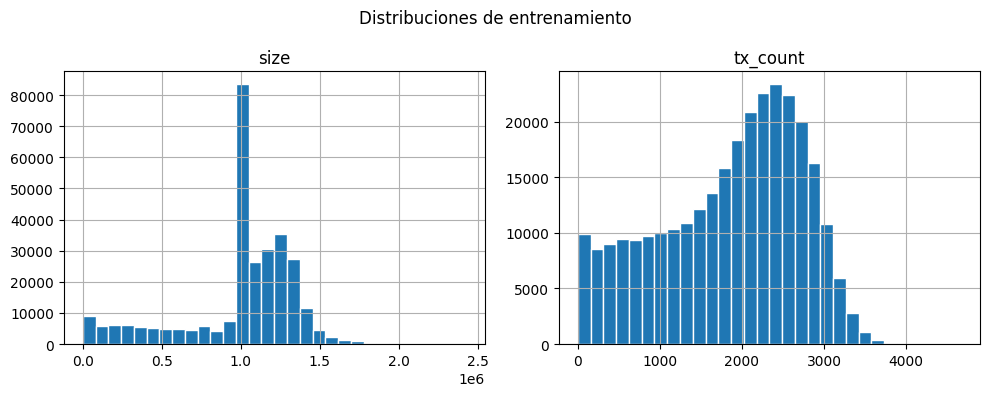

In [13]:
train[["size", "tx_count"]].hist(bins=30, figsize=(10, 4), edgecolor="white")
plt.suptitle("Distribuciones de entrenamiento")
plt.tight_layout()
plt.show()


La tasa mediana se grafica en su escala original para observar el efecto de los valores extremos.


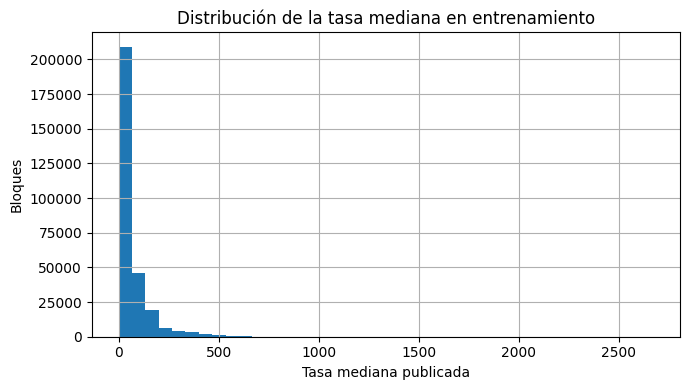

In [14]:
train["median_fee_rate"].hist(bins=40, figsize=(7, 4))
plt.xlabel("Tasa mediana publicada")
plt.ylabel("Bloques")
plt.title("Distribución de la tasa mediana en entrenamiento")
plt.tight_layout()
plt.show()


Unos pocos valores muy grandes extienden el eje horizontal y comprimen la mayor parte de los datos a la izquierda. Esto indica que hay que revisar los extremos; no justifica eliminarlos.

## 14. Tasas cero y bloques con una transacción

Un bloque con `tx_count = 1` contiene solo la transacción coinbase. No se elimina por ese motivo. Se comprueba si también hay tasas cero en bloques con más transacciones.


In [15]:
print("Bloques con una transacción:", (train["tx_count"] == 1).sum())
print("Bloques con tasa mediana cero:", (train["median_fee_rate"] == 0).sum())

con_varias_transacciones = train["tx_count"] > 1
con_tasa_cero = train["median_fee_rate"] == 0
print("Más de una transacción y tasa cero:", (con_varias_transacciones & con_tasa_cero).sum())

Bloques con una transacción: 2612
Bloques con tasa mediana cero: 2929
Más de una transacción y tasa cero: 317


Existen bloques con varias transacciones y tasa mediana cero. Por eso, una tasa cero no identifica por sí sola un bloque con solo coinbase. Se conservan ambos casos; cero no se trata automáticamente como dato faltante.

## 15. Boxplots y valores extremos

El boxplot permite observar la mediana, la dispersión y los valores alejados del resto.


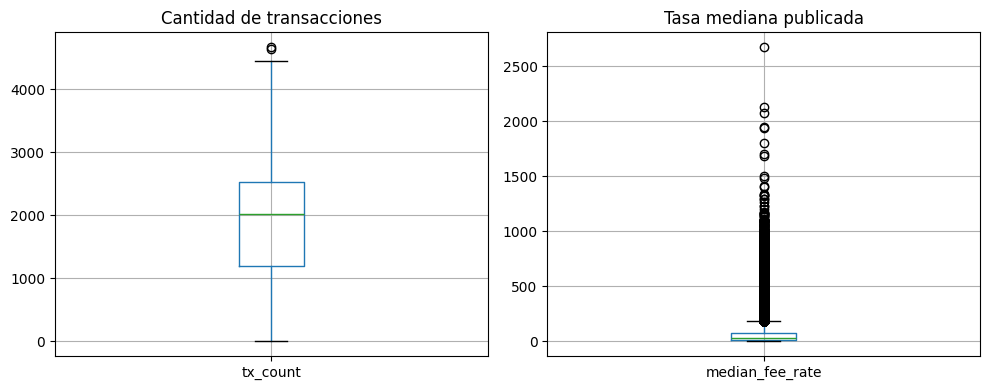

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

train.boxplot(column="tx_count", ax=axes[0])
axes[0].set_title("Cantidad de transacciones")

train.boxplot(column="median_fee_rate", ax=axes[1])
axes[1].set_title("Tasa mediana publicada")

plt.tight_layout()
plt.show()

Se usa la regla del rango intercuartílico: `IQR = Q3 - Q1`. Los valores fuera de `Q1 - 1.5 × IQR` y `Q3 + 1.5 × IQR` se marcan para revisión, pero no se eliminan automáticamente.


In [17]:
q1 = train["median_fee_rate"].quantile(0.25)
q3 = train["median_fee_rate"].quantile(0.75)
iqr = q3 - q1

limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr

extremos = train[(train["median_fee_rate"] < limite_inferior) |
                 (train["median_fee_rate"] > limite_superior)]

print("Límites IQR:", limite_inferior, limite_superior)
print("Bloques marcados:", len(extremos))
print("Porcentaje:", round(len(extremos) / len(train) * 100, 2))
extremos[["height", "median_fee_rate", "tx_count"]].nlargest(5, "median_fee_rate")

Límites IQR: -96.0 184.0
Bloques marcados: 21996
Porcentaje: 7.49


,height,median_fee_rate,tx_count
51794,442976,2673.0,7
68588,459770,2130.0,18
50792,441974,2077.0,5
51962,443144,1945.0,9
69099,460281,1939.0,18


La regla marca 21 996 bloques de entrenamiento (7,49 %). Un extremo puede ser un dato real o una
particularidad de la medición. Se conserva hasta contar con evidencia para corregirlo.

## 16. Variable objetivo y balance de clases

El percentil 75 de las tasas del siguiente bloque en entrenamiento define el umbral. Si la tasa
supera ese valor, la clase es **1: alta**; en otro caso es **0: no alta**. La igualdad con el
umbral pertenece a la clase 0.


In [18]:
umbral = train["tasa_siguiente"].quantile(0.75)
train["clase"] = (train["tasa_siguiente"] > umbral).astype(int)

print("Umbral:", umbral)
train[["height", "median_fee_rate", "tasa_siguiente", "clase"]].head()

Umbral: 79.0


,height,median_fee_rate,tasa_siguiente,clase
0,391182,24.0,1.0,0
1,391183,1.0,24.0,0
2,391184,24.0,10.0,0
3,391185,10.0,24.0,0
4,391186,24.0,26.0,0


Porcentaje por clase:
clase
0    75.08
1    24.92
Name: count, dtype: float64


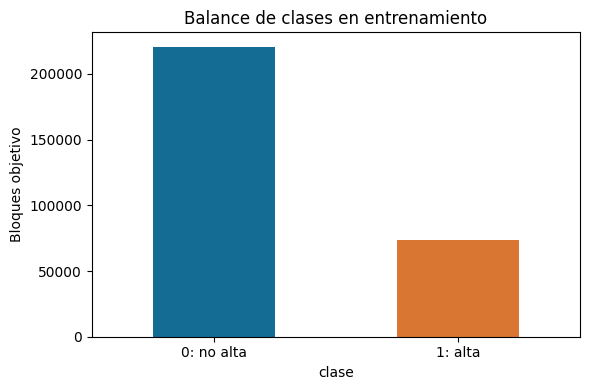

In [19]:
conteos = train["clase"].value_counts().sort_index()
porcentajes = conteos / len(train) * 100

print("Porcentaje por clase:")
print(porcentajes.round(2))

conteos.plot.bar(figsize=(6, 4), rot=0, color=["#146C94", "#D97732"])
plt.xticks([0, 1], ["0: no alta", "1: alta"])
plt.ylabel("Bloques objetivo")
plt.title("Balance de clases en entrenamiento")
plt.tight_layout()
plt.show()


El umbral es 79 en la escala publicada. La clase alta representa el 24,92 % de entrenamiento. Hay
desbalance: predecir siempre «no alta» no demostraría que se identifican los bloques de comisión
alta. La sección 16.1 comprueba si ese umbral mantiene su significado en las demás particiones.


### 16.1 ¿El umbral se traslada a validación y prueba?

El umbral se estimó con entrenamiento, que es lo correcto para evitar fuga de datos. Queda
por comprobar si la clase resultante mantiene una proporción comparable en las demás
particiones. Si la clase positiva casi desaparece en prueba, las métricas calculadas sobre
esa partición no serían informativas.

In [20]:
particiones = {"entrenamiento": train, "validacion": validacion, "prueba": prueba}

filas_balance = []
for nombre, parte in particiones.items():
    fechas = pd.to_datetime(parte["timestamp"], unit="ms", utc=True)
    filas_balance.append({
        "particion": nombre,
        "bloques": len(parte),
        "inicio": fechas.min().date(),
        "fin": fechas.max().date(),
        "mediana_tasa": parte["median_fee_rate"].median(),
        "pct_clase_alta": (parte["tasa_siguiente"] > umbral).mean() * 100,
    })

balance_particiones = pd.DataFrame(filas_balance).set_index("particion")
balance_particiones.round(2)

,bloques,inicio,fin,mediana_tasa,pct_clase_alta
particion,,,,,
entrenamiento,293808,2016-01-01,2021-05-26,29.0,24.92
validacion,62959,2021-05-26,2022-08-04,5.0,0.32
prueba,62960,2022-08-04,2023-10-06,11.0,2.44


La proporción de clase alta es 24,92 % en entrenamiento, **0,32 % en validación** y 2,44 % en
prueba.

Con ese balance, un clasificador que prediga siempre «no alta» obtendría 99,7 % de exactitud en
validación y 97,6 % en prueba sin haber aprendido nada. Ninguna de las dos particiones permitiría
evaluar el modelo según la medida de desempeño definida en la sección 3.

La causa no es un error de cálculo. Entrenamiento cubre de enero de 2016 a mayo de 2021, con una
tasa mediana de 29, mientras que validación cubre de mayo de 2021 a agosto de 2022, con una tasa
mediana de 5. El umbral de 79 no representa lo mismo en ambos tramos.

**El nivel de las comisiones no es estacionario ni siquiera dentro de un periodo donde el
mecanismo de formación del precio es homogéneo.** La delimitación de la sección 10 y la definición
de la clase resuelven problemas distintos: la primera asegura que el fenómeno modelado esté
presente en todo el periodo; la segunda debe adaptarse a un nivel de precio que cambia.

### 16.2 Evolución trimestral de la tasa frente al umbral fijo

El gráfico siguiente muestra la mediana trimestral de `median_fee_rate` junto con el umbral
de 55. Es una revisión estructural del archivo completo, del mismo tipo que las de la
sección 3; no se estima ningún parámetro a partir de validación o prueba.

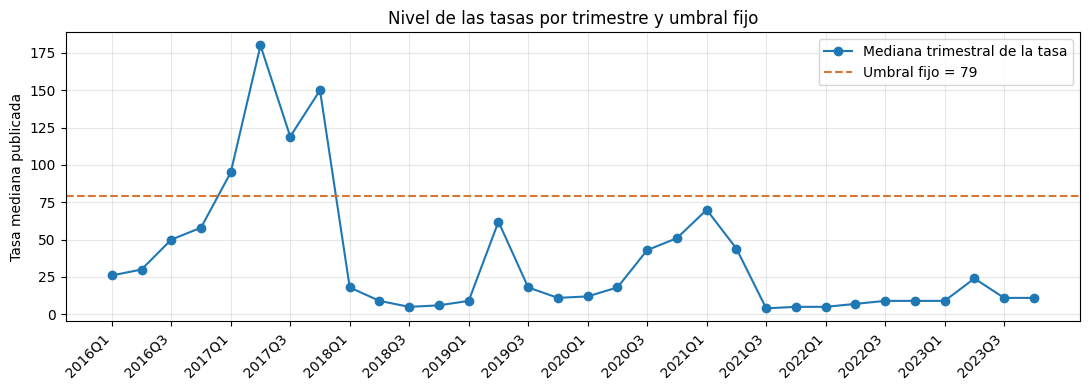

In [21]:
trimestre = pd.to_datetime(datos["timestamp"], unit="ms", utc=True).dt.tz_convert(None).dt.to_period("Q")
mediana_trimestral = datos[trimestre.dt.year >= 2015].groupby(
    trimestre[trimestre.dt.year >= 2015])["median_fee_rate"].median()

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(range(len(mediana_trimestral)), mediana_trimestral.values,
        marker="o", label="Mediana trimestral de la tasa")
ax.axhline(umbral, color="#D97732", linestyle="--",
           label=f"Umbral fijo = {umbral:.0f}")

etiquetas = [str(p) for p in mediana_trimestral.index]
ax.set_xticks(range(0, len(etiquetas), 2))
ax.set_xticklabels(etiquetas[::2], rotation=45, ha="right")
ax.set_ylabel("Tasa mediana publicada")
ax.set_title("Nivel de las tasas por trimestre y umbral fijo")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Durante 2016 y 2017 la mediana trimestral se mantiene por encima del umbral; desde el tercer
trimestre de 2021 permanece muy por debajo, con valores entre 4 y 11. Un umbral constante separa
épocas, no bloques caros de bloques baratos dentro de un mismo contexto.

### 16.3 Redefinición de la clase mediante un umbral móvil

Se conserva el criterio original —la clase alta corresponde al 25 % de bloques con mayor tasa—
pero el percentil 75 se calcula sobre una ventana de bloques anteriores en lugar de sobre todo el
entrenamiento:

$$y_t = 1 \quad \text{si} \quad \text{tasa}_{t+1} > Q_{75}(\text{tasa}_{t-N+1}, \dots, \text{tasa}_t)$$

La ventana usa únicamente bloques hasta el actual, mientras que el objetivo corresponde al bloque
siguiente; por construcción no hay información del futuro. Se emplea N = 1008 bloques, equivalente
a una semana aproximadamente, dado que un bloque se mina cada 10 minutos en promedio.

In [22]:
VENTANA = 1008  # bloques; una semana aproximadamente

datos["umbral_local"] = datos["median_fee_rate"].rolling(VENTANA).quantile(0.75)

movil = datos.dropna(subset=["tasa_siguiente", "umbral_local"]).reset_index(drop=True).copy()
movil["clase_movil"] = (movil["tasa_siguiente"] > movil["umbral_local"]).astype(int)

corte_train_m = int(len(movil) * 0.70)
corte_val_m = int(len(movil) * 0.85)

particiones_moviles = {
    "entrenamiento": movil.iloc[:corte_train_m],
    "validacion": movil.iloc[corte_train_m:corte_val_m],
    "prueba": movil.iloc[corte_val_m:],
}

filas_movil = []
for nombre, parte in particiones_moviles.items():
    fechas = pd.to_datetime(parte["timestamp"], unit="ms", utc=True)
    filas_movil.append({
        "particion": nombre,
        "bloques": len(parte),
        "inicio": fechas.min().date(),
        "fin": fechas.max().date(),
        "pct_clase_alta": parte["clase_movil"].mean() * 100,
    })

pd.DataFrame(filas_movil).set_index("particion").round(2)

,bloques,inicio,fin,pct_clase_alta
particion,,,,
entrenamiento,293104,2016-01-07,2021-05-28,24.65
validacion,62808,2021-05-28,2022-08-05,21.47
prueba,62808,2022-08-05,2023-10-06,24.93


Con el umbral móvil, la proporción de clase alta es 24,65 % en entrenamiento, 21,47 % en
validación y 24,93 % en prueba. Las tres particiones quedan cerca del 25 % previsto por el diseño,
y validación pasa de 0,32 % a 21,47 %.

La clase deja de significar «tasa alta en términos históricos» y pasa a significar «tasa alta
respecto al nivel de la última semana». Es una definición más restrictiva en lo que afirma y más
útil en lo que responde: para decidir si conviene emitir una transacción ahora o esperar, importa
el nivel vigente, no la comparación con épocas pasadas.

Se comprueba la sensibilidad del resultado a la ventana elegida.

In [23]:

filas_sensibilidad = []
for n_ventana in [144, 1008, 4320]:
    tramo = datos.copy()
    tramo["u"] = tramo["median_fee_rate"].rolling(n_ventana).quantile(0.75)
    tramo = tramo.dropna(subset=["tasa_siguiente", "u"]).reset_index(drop=True)
    clase = (tramo["tasa_siguiente"] > tramo["u"]).astype(int)
    a, b = int(len(tramo) * 0.70), int(len(tramo) * 0.85)
    filas_sensibilidad.append({
        "N": n_ventana,
        "equivale_a": {144: "1 día", 1008: "1 semana", 4320: "1 mes"}[n_ventana],
        "train_%": clase[:a].mean() * 100,
        "val_%": clase[a:b].mean() * 100,
        "test_%": clase[b:].mean() * 100,
    })

pd.DataFrame(filas_sensibilidad).round(1)

,N,equivale_a,train_%,val_%,test_%
0,144,1 día,24.2,19.4,24.2
1,1008,1 semana,24.7,21.5,24.9
2,4320,1 mes,26.3,22.6,26.0


El balance entre particiones se mantiene estable para las tres ventanas, de modo que el resultado
no depende de la elección concreta de N. Se conserva N = 1008 porque una semana comprende un ciclo
completo de actividad: la red registra menos transacciones los fines de semana que en días
laborables.

## 17. Relaciones entre variables

Se utiliza la correlación de Pearson. Las entradas corresponden al bloque actual; `tasa_siguiente` corresponde al futuro y se incluye aquí solo para explorar su relación, nunca como entrada del modelo.


In [24]:
variables = ["size", "tx_count", "median_fee_rate", "total_fees", "tasa_siguiente"]
correlacion = train[variables].corr()
correlacion.round(3)


,size,tx_count,median_fee_rate,total_fees,tasa_siguiente
size,1.000,0.677,0.085,0.161,0.067
tx_count,0.677,1.000,0.189,0.227,0.109
median_fee_rate,0.085,0.189,1.000,0.825,0.802
total_fees,0.161,0.227,0.825,1.000,0.711
tasa_siguiente,0.067,0.109,0.802,0.711,1.000


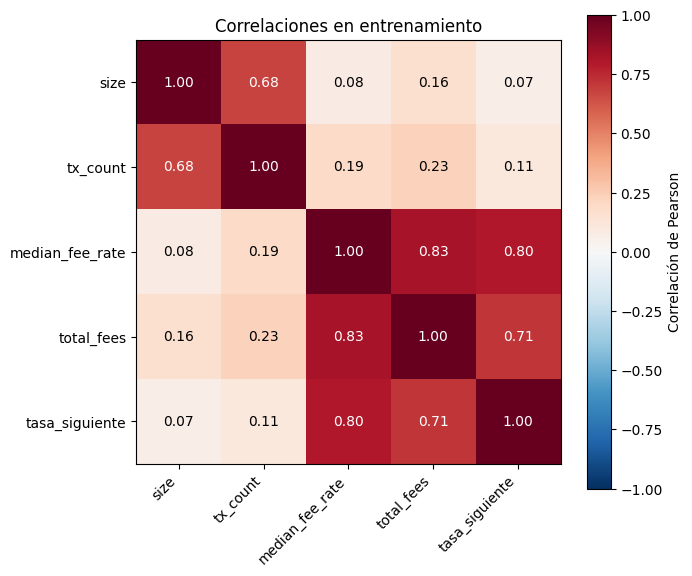

In [25]:
fig, ax = plt.subplots(figsize=(7, 6))
imagen = ax.imshow(correlacion, cmap="RdBu_r", vmin=-1, vmax=1)

ax.set_xticks(range(len(variables)), variables, rotation=45, ha="right")
ax.set_yticks(range(len(variables)), variables)

for i in range(len(variables)):
    for j in range(len(variables)):
        valor = correlacion.iloc[i, j]
        color = "white" if abs(valor) > 0.6 else "black"
        ax.text(j, i, f"{valor:.2f}", ha="center", va="center", color=color)

fig.colorbar(imagen, ax=ax, label="Correlación de Pearson")
ax.set_title("Correlaciones en entrenamiento")
plt.tight_layout()
plt.show()


La correlación lineal entre la tasa actual y la siguiente es 0,802 en el periodo de estudio. La
tasa del bloque actual es, por sí sola, un predictor fuerte de la del siguiente, lo que sustenta
la hipótesis H1 y fija una referencia exigente para la medida de desempeño P: cualquier modelo
debe superar la regla «la clase del siguiente bloque es la del actual».

El tamaño del bloque y el número de transacciones muestran correlaciones bajas con el objetivo
(0,067 y 0,109). La sección 17.1 examina si esa debilidad se mantiene al usar correlación de
rangos.

Un diagrama de dispersión complementa la tabla. Se toma una muestra reproducible de 2 000 pares
solo para facilitar la visualización; las estadísticas anteriores usan todo entrenamiento.


### 17.1 Correlación de rangos y correlación por época

La correlación de Pearson mide asociación **lineal** y es sensible a valores extremos. Se añade la
correlación de **Spearman**, que trabaja sobre rangos, y se repite el cálculo separando el periodo
de estudio en épocas de dos años.

In [26]:
correlacion_spearman = train[variables].corr(method="spearman")
correlacion_spearman.round(3)

,size,tx_count,median_fee_rate,total_fees,tasa_siguiente
size,1.000,0.596,0.093,0.295,0.002
tx_count,0.596,1.000,0.287,0.432,0.113
median_fee_rate,0.093,0.287,1.000,0.878,0.709
total_fees,0.295,0.432,0.878,1.000,0.678
tasa_siguiente,0.002,0.113,0.709,0.678,1.000


Con correlación de rangos, la tasa mediana mantiene una asociación fuerte con el objetivo (0,709)
y las comisiones totales del bloque también (0,678). En cambio el tamaño del bloque baja de 0,067 a
0,002 y el número de transacciones se mantiene en 0,113: **no son predictores útiles por sí solos
dentro de este periodo.**

El resultado es coherente con el mecanismo descrito en la sección 10. Una vez que los bloques se
llenan de forma habitual, su tamaño deja de informar sobre la congestión, porque casi todos están
igualmente llenos; lo que varía es el precio que se paga por entrar. El tamaño solo discriminaría
en un contexto donde algunos bloques se llenan y otros no.

Esto acota la hipótesis H2: la mejora marginal esperada procede de las comisiones totales y de
variables derivadas aún por construir, no del tamaño del bloque.

A continuación se separa el periodo de estudio en épocas de dos años.

In [27]:
import numpy as np

fecha_completa = pd.to_datetime(datos["timestamp"], unit="ms", utc=True)

epocas = [("2016-2017", 2016, 2017), ("2018-2019", 2018, 2019),
          ("2020-2021", 2020, 2021), ("2022-2023", 2022, 2023)]

filas_epoca = []
for etiqueta, anio_inicio, anio_fin in epocas:
    en_epoca = (fecha_completa.dt.year >= anio_inicio) & (fecha_completa.dt.year <= anio_fin)
    tramo = datos[en_epoca].dropna(subset=["tasa_siguiente"])
    filas_epoca.append({
        "epoca": etiqueta,
        "bloques": len(tramo),
        "pearson": tramo["median_fee_rate"].corr(tramo["tasa_siguiente"]),
        "spearman": tramo["median_fee_rate"].corr(tramo["tasa_siguiente"], method="spearman"),
        "pearson_log": np.log1p(tramo["median_fee_rate"]).corr(np.log1p(tramo["tasa_siguiente"])),
    })

correlacion_por_epoca = pd.DataFrame(filas_epoca).set_index("epoca")
correlacion_por_epoca.round(3)

,bloques,pearson,spearman,pearson_log
epoca,,,,
2016-2017,110779,0.760,0.666,0.512
2018-2019,108730,0.851,0.565,0.645
2020-2021,105908,0.767,0.712,0.710
2022-2023,94310,0.904,0.640,0.665


La correlación entre la tasa actual y la siguiente se mantiene entre 0,760 y 0,904 en las cuatro
épocas, sin tendencia definida. La relación es **estable dentro del periodo de estudio**, lo que
confirma que los bloques posteriores a 2016 describen un único mecanismo de formación del precio y
respalda la delimitación adoptada en la sección 10.

La estabilidad de esta relación no implica que el nivel de las comisiones sea estable: la sección
16 documenta lo contrario. Son propiedades distintas, y por eso el periodo se delimita y además la
clase se define de forma relativa.

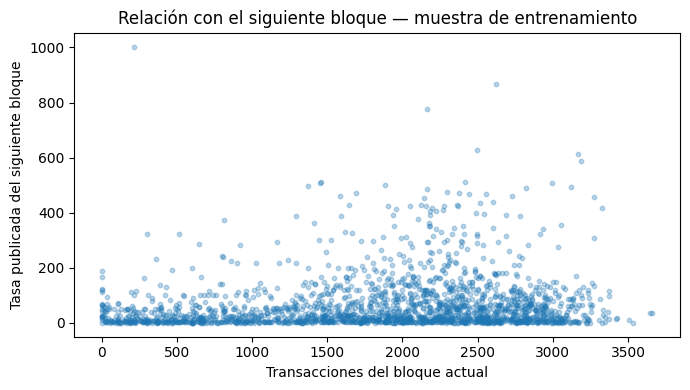

In [28]:
muestra = train.sample(2000, random_state=42)

plt.figure(figsize=(7, 4))
plt.scatter(muestra["tx_count"], muestra["tasa_siguiente"], s=10, alpha=0.3)
plt.xlabel("Transacciones del bloque actual")
plt.ylabel("Tasa publicada del siguiente bloque")
plt.title("Relación con el siguiente bloque — muestra de entrenamiento")
plt.tight_layout()
plt.show()


Las asociaciones observadas son descriptivas. No permiten atribuir causalidad ni anticipar el rendimiento de un clasificador. La evaluación de modelos se desarrollará posteriormente.


## 18. Evolución de las tasas por año

Se convierte `timestamp` a fecha, se obtiene el año y se agrupan los bloques de **entrenamiento**.
Para cada año se calcula la mediana de `median_fee_rate`.

El resultado es la **mediana anual de las tasas publicadas por bloque**, no la mediana de todas las
transacciones del año. La columna `bloques` indica cuántas observaciones aporta cada periodo.

Entrenamiento abarca de enero de 2016 a mayo de 2021: 2021 está incompleto. Validación y prueba no
se utilizan en este gráfico.

In [29]:
anio = pd.to_datetime(train["timestamp"], unit="ms", utc=True).dt.year

evolucion_anual = train.groupby(anio)["median_fee_rate"].agg(["count", "median"])
evolucion_anual.columns = ["bloques", "mediana_tasa"]
evolucion_anual.index.name = "anio"

evolucion_anual


,bloques,mediana_tasa
anio,,
2016,54851,39.0
2017,55928,134.0
2018,54498,8.0
2019,54232,16.0
2020,53222,21.0
2021,21077,70.0


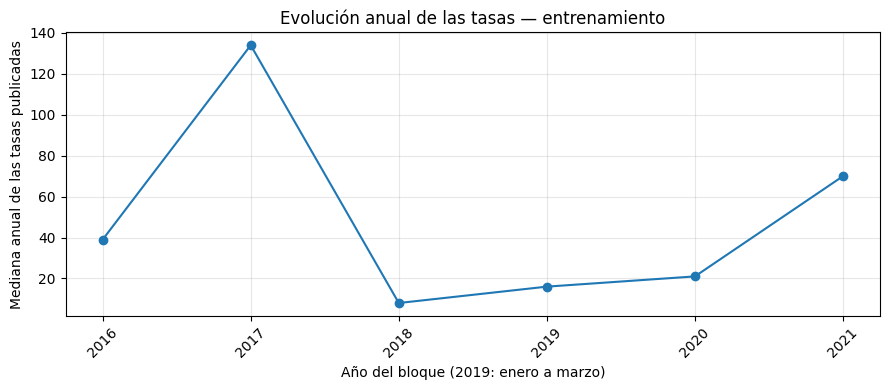

In [30]:
evolucion_anual["mediana_tasa"].plot(figsize=(9, 4), marker="o")
plt.xticks(evolucion_anual.index, rotation=45)
plt.xlabel("Año del bloque (2019: enero a marzo)")
plt.ylabel("Mediana anual de las tasas publicadas")
plt.title("Evolución anual de las tasas — entrenamiento")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


La mediana anual alcanza 134 en 2017 y desciende a 8 en 2018; 2021 aporta solo 21 077 bloques por
estar incompleto. Aun dentro de un periodo con mecanismo homogéneo, el nivel de las tasas varía por
un factor cercano a 17 entre años.

Esta observación es el fundamento empírico de la sección 16.3: la delimitación del periodo
homogeneiza el **mecanismo**, pero no el **nivel**.

## 19. Prevención de fuga de datos (data leakage)

La fuga de datos ocurre cuando el modelo accede, durante el entrenamiento, a información que no
estaría disponible en el momento de la predicción. Se aplican cinco medidas explícitas:

1. **Partición temporal, no aleatoria.** Los bloques se ordenan por `height` y se cortan en tres
   tramos consecutivos. Una partición aleatoria permitiría entrenar con bloques posteriores a los
   evaluados.
2. **Umbral estimado solo con el pasado.** El umbral móvil de cada fila se calcula con la ventana
   de bloques anteriores a esa fila; nunca con bloques posteriores, ni con validación o prueba.
3. **Orientación del objetivo.** `tasa_siguiente` se obtiene con `shift(-1)`, de modo que
   corresponde al bloque posterior. Se utiliza únicamente como variable objetivo y nunca como
   entrada del modelo.
4. **Margen entre particiones.** Al construir variables con ventanas móviles, las primeras filas de
   validación y prueba reutilizan bloques del tramo anterior. Se descartará un margen del tamaño de
   la ventana más larga entre particiones, mediante el parámetro `gap` de `TimeSeriesSplit`.
5. **Delimitación del periodo previa al modelado.** El corte de la sección 10 se decide a partir de
   la ocupación de los bloques y de la persistencia de la tasa, no del desempeño de ningún modelo
   ni de las métricas de validación o prueba.

**Nota sobre los diagnósticos de la sección 16.1.** El conteo de clases en validación y prueba se
realiza como revisión estructural del diseño experimental, del mismo tipo que la revisión de nulos
y duplicados sobre el archivo completo. No se estima ningún parámetro del modelo a partir de esas
particiones, ni se selecciona configuración alguna en función de su desempeño. Se declara
explícitamente para que la decisión quede auditable.

## 20. Siguientes pasos

**Construcción de variables derivadas.**

- Ocupación del bloque, normalizada por el máximo de una ventana móvil y no por el límite nominal
  de 1 MB, dado que SegWit (agosto de 2017) modificó la forma de medir la capacidad del bloque
  dentro del periodo de estudio.
- Tiempo transcurrido entre bloques consecutivos, como indicador de acumulación de demanda sin
  procesar.
- Tamaño medio de transacción, entradas y salidas por transacción.
- Razón entre `avg_fee_rate` y `median_fee_rate`, como indicador de dispersión de las comisiones
  dentro del bloque: un valor elevado señala que algunas transacciones pagaron muy por encima del
  resto, lo que indica competencia activa por prioridad.
- Rezagos y ventanas móviles de la tasa mediana.
- Variables de calendario: hora del día y día de la semana.

**Modelado y evaluación.**

- Referencia de persistencia: predecir para el bloque siguiente la clase observada en el actual.
  Ningún modelo se considerará útil si no la supera.
- Regresión logística con regularización como modelo principal, por su interpretabilidad y por
  corresponder al contenido del curso.
- Validación con ventana expansiva (`TimeSeriesSplit` con `gap` igual a la ventana más larga
  empleada en las variables derivadas), reportando media y desviación entre pliegues.
- Métricas de la sección 3: F1 sobre la clase alta y PR-AUC. La exactitud se reportará únicamente
  como referencia secundaria.
- **Contraste de H3:** evaluación segmentada según el nivel de variación de las comisiones,
  comparando el desempeño en tramos estables y en episodios de cambio brusco.

## 21. Limitaciones

- **Ausencia del mempool.** No se dispone del estado de la cola de transacciones pendientes, que es
  información central en la literatura sobre estimación de comisiones. La congestión se aproxima
  mediante la ocupación de los bloques y las propias tasas observadas.
- **Sesgo de selección.** Solo se observan transacciones confirmadas. Las ofertas insuficientes no
  quedan registradas, de modo que se observa el resultado de la subasta y no el conjunto de
  ofertas.
- **Agregación.** Los resultados describen el comportamiento del mercado y no permiten inferencia
  directa sobre transacciones individuales.
- **Delimitación del periodo.** El estudio excluye los bloques anteriores a 2016, de modo que sus
  conclusiones no son extrapolables a contextos donde el espacio en bloque no sea escaso.
- **Inconsistencias de la fuente.** 2 512 bloques del archivo presentan la mediana fuera del rango
  publicado (sección 9.2).
- **Dependencia entre observaciones.** Los bloques consecutivos están separados por unos diez
  minutos y son fuertemente dependientes entre sí. El tamaño de muestra efectivo es menor que el
  nominal, por lo que diferencias pequeñas entre modelos no serán concluyentes.

## Referencias

- Jesús Graterol. [Bitcoin Blockchain Historical Data](https://www.kaggle.com/datasets/jesusgraterol/bitcoin-blockchain-dataset), Kaggle.
- Jesús Graterol. [Generador y esquema del dataset](https://github.com/jesusgraterol/bitcoin-blockchain-dataset-builder).
- Bitcoin Developer Documentation. [Block Chain](https://developer.bitcoin.org/reference/block_chain.html), transacción coinbase.
